# Synthetischer Datensatz — Adaption

Adaptiert das in *synthetic_data_model.ipynb* trainierte MLP an den drift-behafteten
Strom mit vier Strategien (Baseline, Passiv, Aktiv, Kombiniert) sowie der passiven
Strategie mit Recurrence-Selektor (`blind_rec`, Masterarbeit Abschn. 5.5.3: Rückholung
vergangener Punkte mit ähnlichem Fehler); Module `drift_adaptation.py` / `drift_detection.py`.

Die Einteilung folgt Gama et al. (2014, Abschn. 3.3.2): *blind* = rein periodisches
Nachtraining ohne Fehlerauswertung, *informed* = trigger-basiert. Als Trigger werden
alle fünf Detektoren gescreent — die vier statistischen Verfahren sowie der
Schwellwert-Detektor `RMSE`, der die Überwachung eines Performance-Indikators
(Gama Abschn. 3.2) in ihrer einfachsten Form darstellt. Die aktive und die
kombinierte Strategie werden anschließend mit dem im Screening besten Detektor
ausgewertet.

In [1]:
FORCE_RECOMPUTE = False   
IS_FINAL = True

In [2]:
# --- Konstanten ---
RUN_ID = "e7f8df2f"   # None -> neuestes Modell

SEED = 42

STEP_S = 600                 # Abtastung des Adaptionsstroms
STEP_TUNE_S = 3600           # groebere Abtastung fuers Tuning
DETECTORS = ("KSWIN", "ADWIN", "DDM", "EDDM", "RMSE")
N_TRIALS = {"screening": 40, "final": 60}
TUNE_WEIGHTS = (1.0, 0.1)
# Refraktaerzeit zwischen zwei Sofort-Trainings (x * T_stat); cooldown wird als cooldown_x in [0, 60] getunt
COOLDOWN_X = 30
# Update-Validierung: Nachtraining verwerfen, wenn der MSE nicht sinkt
REJECT = True
REFERENCE_PARAMS = {
    'blind':           {'lr': 0.007780840581844165, 'epochs': 12, 'freeze': (True, False, False), 'reset': False, 'blind_window': 100, 'blind_period': 67},
    'informed@KSWIN':  {'lr': 0.009335983887971746, 'epochs': 10, 'freeze': (True, False, False), 'reset': False, 'window_prev': 94, 'window_post': 97, 'cooldown_x': 1.409115561561844, 'det_min_num_instances': 97, 'det_alpha': 2.0896012754353465e-06, 'det_num_test_instances': 20},
    'informed@ADWIN':  {'lr': 0.006324733660132021, 'epochs': 10, 'freeze': (False, False, False), 'reset': False, 'window_prev': 99, 'window_post': 45, 'cooldown_x': 23.5855586000961, 'det_delta': 0.0010149189435816283, 'det_clock': 49, 'det_min_window_size': 5},
    'informed@DDM':    {'lr': 0.001036975580847369, 'epochs': 6, 'freeze': (True, False, False), 'reset': False, 'window_prev': 57, 'window_post': 24, 'cooldown_x': 8.35760680628955, 'det_drift_level': 2.073553346372523, 'det_min_num_instances': 169, 'det_err_threshold': 1.6931050627921067},
    'informed@EDDM':   {'lr': 0.00022518081481930348, 'epochs': 20, 'freeze': (True, False, False), 'reset': False, 'window_prev': 75, 'window_post': 84, 'cooldown_x': 21.23463163657574, 'det_alpha': 0.9805773158384067, 'det_beta': 0.9773005712680071, 'det_min_num_misclassified_instances': 46, 'det_err_threshold': 2.0025080621468834},
    'informed@RMSE':   {'lr': 0.003631228929191709, 'epochs': 19, 'freeze': (False, False, False), 'reset': False, 'window_prev': 55, 'window_post': 26, 'cooldown_x': 5.089048781057097, 'det_window': 81, 'det_threshold': 1.4338732352501131},
    'informed':        {'lr': 0.009335983887971746, 'epochs': 10, 'freeze': (True, False, False), 'reset': False, 'window_prev': 94, 'window_post': 97, 'cooldown_x': 1.409115561561844, 'det_min_num_instances': 97, 'det_alpha': 2.0896012754353465e-06, 'det_num_test_instances': 20},
    'combined':        {'lr': 0.00623931782448686, 'epochs': 20, 'freeze': (True, False, False), 'reset': False, 'blind_window': 100, 'blind_period': 67, 'window_prev': 77, 'window_post': 66, 'cooldown_x': 16.873072222561234, 'det_min_num_instances': 103, 'det_alpha': 2.3766491945383896e-06, 'det_num_test_instances': 39},
}

# Optima des Laufs vom 2026-09-03, bevor vier Grenzen des Suchraums geoeffnet
# wurden (epochs 20->30, blind_window 100->400, window_prev/post 100->300).
# Sie werden je Fall als Startkandidat eingereiht: der groessere Suchraum wird
# mit unveraendertem Budget durchsucht, ohne Referenz koennte das Ergebnis
# schlechter ausfallen als das bisherige. Alle Werte liegen innerhalb der neuen
# Grenzen, es wird also -- anders als beim frueheren Warmstart aus der
# Detektion -- kein Wert ausserhalb des Suchraums eingereiht.

N_SEED_RUNS = 50              # Zielzahl an Laeufen mit identischer Konfiguration

import numpy as np
SCREENING_SEEDS = (SEED, *np.random.default_rng(SEED).integers(1, 2**10 - 1, size=4).tolist())

In [3]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "synthetic_data"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

## Daten und Basismodell laden

In [4]:
import pandas as pd
from src.utils import run_registry as rr
rr.assert_current()

data_store = rr.synthetic_data_store(data_dir)
model_store = rr.synthetic_model_store(model_dir)

if RUN_ID is None:
    run_id = model_store.latest_id("model")
    if run_id is None:
        raise FileNotFoundError("Kein data-Artefakt. Bitte syn_model.ipynb ausfuehren.")
else:
    run_id = RUN_ID
print(f"model run_id = {run_id}")

rng = np.random.default_rng(SEED)
test_data = data_store.load("data_test", run_id=run_id, rename=True, rekey=True)
test_cfg = rr.RunConfig.from_document(test_data.attrs.get("config", test_data.attrs))

_mc = model_store.load("model", run_id=run_id, rename=True)
base_model = _mc["model"]
X_scaler = _mc["X_scaler"]
y_scaler = _mc["y_scaler"]

ledger = rr.run_ledger(work_dir)
ledger.bind("adaptation", parents={"model": test_cfg.id})
plot_store = rr.synthetic_plot_store(plot_dir, ledger=ledger)
res_store  = rr.synthetic_results_store(results_dir, ledger=ledger)

model run_id = e7f8df2f


c:\git\process_optimization_concept_drift\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\git\process_optimization_concept_drift\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
STRIDE = max(1, STEP_S // 60)
stream = test_data.iloc[::STRIDE].copy()
N = len(stream)
print(f"Adaptionsstrom: {N} Punkte (STEP={STEP_S}s, STRIDE={STRIDE})")

X_free = X_scaler.transform(stream[["u1_noise_filt", "u2_noise_filt"]].to_numpy()).astype("float32")
y_free = y_scaler.transform(stream[["y_noise_filt"]].to_numpy()).ravel().astype("float32")

X_cd = X_scaler.transform(stream[["u1_cd_noise_filt", "u2_cd_noise_filt"]].to_numpy()).astype("float32")
y_cd = y_scaler.transform(stream[["y_cd_noise_filt"]].to_numpy()).ravel().astype("float32")

cd_signal = stream["cd"].to_numpy()
time_index = stream.index

Adaptionsstrom: 52560 Punkte (STEP=600s, STRIDE=10)


## Adaptionsstrategien

In [6]:
import tensorflow as tf
import drift_adaptation as da
from drift_adaptation import run_adaptation, StreamingDetector

# Ein laufender Kernel haelt das Modul fest; assert_current bricht ab, wenn die
# Datei inzwischen abweicht. SPACE_ID kommt aus dem GELADENEN Code-Objekt und
# geht in die Cache-Schluessel ein, damit eine geaenderte Grenze in
# _suggest_adapt_params den Cache verwirft statt ihn stillschweigend zu treffen.
da.assert_current()
SPACE_ID = da.adapt_space_id()
print(f"Suchraum-Kennung: {SPACE_ID}")

Suchraum-Kennung: c3683005


## Detektor-Konfiguration (für die Informed-Adaption)

Die Detektorparameter werden **nicht** aus *syn_detection* übernommen, sondern im geschlossenen Regelkreis mitgetunt (`_suggest_adapt_params` in `drift_adaptation.py`): das Fehlerniveau nach einem Nachtraining unterscheidet sich vom statischen Fehlerstrom des Detektions-Notebooks, dort kalibrierte Werte sind hier systematisch fehlangepasst.

`make_detector` liefert deshalb nur die Hülle; `apply_det_params` setzt vor jedem Trial und jedem Lauf die getunten Werte. Ein Warmstart aus `syn_detection.json` wäre zudem in zweifacher Hinsicht unbrauchbar: er überträgt Schrittzahlen von einem 60-s-Strom auf das `STEP_TUNE_S`-Raster, und für DDM und EDDM läge sein `err_threshold` außerhalb des hier gesuchten Bereichs — Optuna benutzt einen solchen Wert unverändert weiter, statt ihn zu begrenzen, und verzerrt damit die erste Beobachtung.

In [7]:
import json   # fuer das Scannen des Seed-Archivs weiter unten


def make_detector(name):
    """Frischer StreamingDetector aus den Modul-Defaults von drift_detection.py.

    Konstruktionswerte bleiben ohne Wirkung: apply_det_params ueberschreibt vor
    jedem Lauf saemtliche Detektorparameter mit den im Adaptions-Tuning
    optimierten (s. Markdown darueber).
    """
    return StreamingDetector(name)


def detector_factory(name):
    return lambda: make_detector(name)

In [8]:
_base_free_pred = base_model.predict(X_free, verbose=0).ravel()
_base_free_err = y_free - _base_free_pred
NORM_MEAN = float(np.mean(_base_free_err))
NORM_STD = float(np.std(_base_free_err)) or 1.0
print(f"Normierungs-Baseline: mean={NORM_MEAN:.4g}, std={NORM_STD:.4g}")

Normierungs-Baseline: mean=-0.0009897, std=0.008199


## Hyperparameter-Tuning der Adaption

In [9]:
STRIDE_TUNE = max(1, STEP_TUNE_S // 60)

_tune = test_data.iloc[::STRIDE_TUNE]
X_tune = X_scaler.transform(_tune[["u1_cd_noise_filt", "u2_cd_noise_filt"]].to_numpy()).astype("float32")
y_tune = y_scaler.transform(_tune[["y_cd_noise_filt"]].to_numpy()).ravel().astype("float32")

_, T_STAT_TUNE = da.estimate_cooldown(_tune[["w1", "w2"]], x=COOLDOWN_X)

CHUNK_TUNE = max(24, 86400 // STEP_TUNE_S)
TUNE_FIXED = dict(chunk=CHUNK_TUNE, reject=REJECT,
                  norm_mean=NORM_MEAN, norm_std=NORM_STD, seed=SEED)

best_adapt_params, studies, tune_cfgs = {}, {}, {}

def _tune_case(key, strategy, n_trials, det_name=None, enqueue=None, extra_cfg=None):
    """Tunt einen Fall und cached ihn ueber die RunConfig-Kennung."""
    tune_params = {"method": strategy, "case": key, "n_trials": n_trials,
                   "weights": list(TUNE_WEIGHTS), "step_tune_s": STEP_TUNE_S,
                   "step_s": STEP_S, "space": SPACE_ID,
                   "reference": REFERENCE_PARAMS.get(key),
                   "scheme": "phase-extend", "cooldown_tuned": True,
                   **({"detector": det_name} if det_name else {}),
                   **(extra_cfg or {}),
                   **{k: TUNE_FIXED[k] for k in sorted(TUNE_FIXED)
                      if not k.startswith("norm_")}}
    tune_cfgs[key] = test_cfg.compose(tuning=tune_params)
    if (model_store.exists("adapt_tuning", tune_cfgs[key], rekey=True)
            and not FORCE_RECOMPUTE):
        best_adapt_params[key] = model_store.load("adapt_tuning", tune_cfgs[key], rekey=True)
        print(f"{key:18s} aus Cache")
        return
    tf.keras.utils.set_random_seed(SEED)
    # Referenzpunkt des vorigen Laufs voranstellen (s. REFERENCE_PARAMS).
    _ref = REFERENCE_PARAMS.get(key)
    if _ref is not None:
        enqueue = [da.encode_adapt_params(_ref)] + list(enqueue or [])
    _fac = detector_factory(det_name) if det_name else None
    _study, _ = da.tune_adaptation(strategy, base_model, X_tune, y_tune,
                                   fixed=TUNE_FIXED, detector_factory=_fac,
                                   n_trials=n_trials, weights=TUNE_WEIGHTS,
                                   seed=SEED, enqueue=enqueue, t_stat=T_STAT_TUNE)
    studies[key] = _study
    best_adapt_params[key] = da.decode_adapt_params(_study.best_params)
    _a = _study.best_trial.user_attrs
    print(f"{key:18s} score={_study.best_value:.3f} | rmse={_a['rmse']:.3f} "
          f"n_train={_a['n_train']:3d} n_detect={_a['n_detect']:3d}")
    model_store.save(best_adapt_params[key], "adapt_tuning", tune_cfgs[key])

# --- Passive Strategie (detektorfrei, finale Konfiguration direkt) ---
_tune_case("blind", "blind", N_TRIALS["final"])
# Recurrence-Selektor auf der passiven Strategie; das blind-Optimum wird als
# Teilkandidat eingereiht (fehlende Selektorparameter zieht Optuna selbst).
_tune_case("blind_rec", "blind_rec", N_TRIALS["final"],
           enqueue=[da.encode_adapt_params(best_adapt_params["blind"])])

# --- Screening: informierte Strategie je Detektor, reduziertes Budget ---
# Ohne Warmstart: jeder Detektor startet unter denselben Bedingungen, sonst
# waere der Vergleich, aus dem BEST_DETECTOR folgt, nicht fair.
print(f"\nDetektor-Screening ({N_TRIALS['screening']} Trials je Detektor)")
for _det in DETECTORS:
    _tune_case(f"informed@{_det}", "informed", N_TRIALS["screening"], det_name=_det)

blind              aus Cache
blind_rec          aus Cache

Detektor-Screening (40 Trials je Detektor)
informed@KSWIN     aus Cache
informed@ADWIN     aus Cache
informed@DDM       aus Cache
informed@EDDM      aus Cache
informed@RMSE      aus Cache


In [10]:
from scipy import stats

# Gegenpruefung des Screenings auf dem voll aufgeloesten Strom. Ausgewaehlt wird
# der Detektor mit dem kleinsten mittleren RMSE ueber SCREENING_SEEDS; das
# Tuning laeuft auf einem groeber abgetasteten Strom, die Uebertragung der
# Konfiguration ist daher eine Extrapolation und muss geprueft werden. Ein
# einzelner Seed reicht dafuer nicht: die Abstaende zwischen den Detektoren
# sind kleiner als die Seed-Streuung derselben Strategie (informed mit DDM
# +/- 0,15 bei 11 Seeds, Screening-Abstand DDM/RMSE 0,01).
_RESCALE = STRIDE_TUNE / STRIDE
CHUNK = max(24, 86400 // STEP_S)
_BASE_CFG = dict(chunk=CHUNK, reject=REJECT, norm_mean=NORM_MEAN, norm_std=NORM_STD)
COOLDOWN, T_stat = da.estimate_cooldown(stream[["w1", "w2"]], x=COOLDOWN_X)

_scr_cfg = test_cfg.compose(screening={
    "detectors": sorted(DETECTORS), "step_s": STEP_S, "cooldown_x": COOLDOWN_X,
    "space": SPACE_ID,
    "rescale": _RESCALE, "reject": REJECT,
    "seeds": [int(s) for s in SCREENING_SEEDS],
    "params": {d: da.encode_adapt_params(best_adapt_params[f"informed@{d}"])
               for d in DETECTORS}})

if model_store.exists("adapt_screening", _scr_cfg, rekey=True) and not FORCE_RECOMPUTE:
    screening = model_store.load("adapt_screening", _scr_cfg, rekey=True)
    print("Screening aus Cache")
else:
    screening = {}
    for _det in DETECTORS:
        _key = f"informed@{_det}"
        _rmse, _ntr = [], []
        for _sd in SCREENING_SEEDS:
            _, _tab = da.crosscheck_candidates(
                base_model, X_cd, y_cd,
                best_params={"informed": best_adapt_params[_key]}, fixed=_BASE_CFG,
                t_stat=T_stat, detector_factory=detector_factory(_det),
                study=None, top_k=0, rescale=_RESCALE, mode="informed", seed=int(_sd),
                verbose=False)
            _rmse.append(float(_tab["tpe_best"]["rmse"]))
            _ntr.append(int(_tab["tpe_best"]["n_train"]))
        screening[_det] = {"rmse": float(np.mean(_rmse)), "rmse_std": float(np.std(_rmse, ddof=1)),
                           "rmse_seeds": _rmse, "n_train": float(np.mean(_ntr))}
        print(f"{_det:6s} RMSE={screening[_det]['rmse']:.4f} "
              f"+/- {screening[_det]['rmse_std']:.4f}  "
              f"({', '.join(f'{r:.3f}' for r in _rmse)})  "
              f"n_train={screening[_det]['n_train']:.0f}")

    model_store.save(screening, "adapt_screening", _scr_cfg)

# Rangfolge bei Gleichstand: Verfahren mit den wenigsten Annahmen zuerst
# (Schwelle auf dem Indikator -> fehlerratenbasiert -> fensterbasierte Tests).
TIE_ORDER = ("RMSE", "DDM", "EDDM", "ADWIN", "KSWIN")
TIE_ALPHA = 0.05

_lead = min(screening, key=lambda d: screening[d]["rmse"])
_tied = []
for _det in DETECTORS:
    if _det == _lead:
        _tied.append(_det); continue
    _p = stats.ttest_rel(screening[_det]["rmse_seeds"], screening[_lead]["rmse_seeds"]).pvalue
    screening[_det]["p_vs_lead"] = float(_p)
    if _p > TIE_ALPHA:
        _tied.append(_det)
screening[_lead]["p_vs_lead"] = 1.0
BEST_DETECTOR = min(_tied, key=TIE_ORDER.index)
SCREEN_LEAD = _lead          # kleinster mittlerer RMSE
SCREEN_TIED = tuple(_tied)   # davon statistisch nicht zu unterscheiden

print(f"\nKleinster RMSE: {_lead}; gleichwertig (gepaart, p > {TIE_ALPHA}): {_tied}")
print(f"Gewaehlter Detektor: {BEST_DETECTOR} "
      f"(RMSE={screening[BEST_DETECTOR]['rmse']:.4f} "
      f"+/- {screening[BEST_DETECTOR]['rmse_std']:.4f} ueber {len(SCREENING_SEEDS)} Seeds)")

screening_table = pd.DataFrame(
    {d: {"rmse": v["rmse"], "rmse_std": v["rmse_std"], "p_vs_lead": v["p_vs_lead"],
         "n_train": v["n_train"]} for d, v in screening.items()}).T

Screening aus Cache

Kleinster RMSE: KSWIN; gleichwertig (gepaart, p > 0.05): ['KSWIN', 'DDM', 'RMSE']
Gewaehlter Detektor: RMSE (RMSE=0.7125 +/- 0.0225 ueber 5 Seeds)


In [11]:
# Der gewaehlte Detektor wird mit vollem Budget nachgetunt (Warmstart mit dem
# Screening-Optimum), danach die kombinierte Strategie mit demselben Detektor
# (Warmstart mit der Vereinigung der Einzeloptima).
_scr = best_adapt_params[f"informed@{BEST_DETECTOR}"]
_tune_case("informed", "informed", N_TRIALS["final"], det_name=BEST_DETECTOR,
           enqueue=[da.encode_adapt_params(_scr)])

_bl, _inf = best_adapt_params["blind"], best_adapt_params["informed"]
_tune_case("combined", "combined", N_TRIALS["final"], det_name=BEST_DETECTOR,
           enqueue=[da.encode_adapt_params({**_bl, **_inf}),
                    da.encode_adapt_params({**_inf, **_bl})])

# --- Gegenpruefung auf voller Aufloesung -------------------------------------
# Eigener Cache-Fall: der Crosscheck darf NICHT nach "adapt_tuning" zurueck-
# schreiben, sonst laedt _tune_case beim naechsten Lauf sein eigenes Ergebnis
# und die Gegenpruefung startet von einem anderen Kandidatensatz.
# Der Schluessel haengt an den TPE-Optima (= Eingang), damit er inhalts-
# adressiert und ueber Laeufe hinweg stabil ist.
_CC_KEYS = ("blind", "informed", "combined", "blind_rec")
_cc_cfg = test_cfg.compose(crosscheck={
    "detector": BEST_DETECTOR,
    "space": SPACE_ID,
    "step_s": STEP_S,
    "cooldown_x": COOLDOWN_X,
    "rescale": float(_RESCALE),
    "reject": REJECT,
    "chunk": CHUNK,
    "top_k": 3,
    "tpe": {k: da.encode_adapt_params(best_adapt_params[k]) for k in _CC_KEYS},
})

if model_store.exists("adapt_crosscheck", _cc_cfg, rekey=True) and not FORCE_RECOMPUTE:
    best_adapt_params.update(model_store.load("adapt_crosscheck", _cc_cfg, rekey=True))
    print(f"Crosscheck aus Cache ({BEST_DETECTOR})")
    for _m in _CC_KEYS:
        print(f"  {_m:9s} {best_adapt_params[_m]}")
else:
    # informed zuerst, da der union-Kandidat der kombinierten Strategie dessen
    # Optimum nutzt.
    _extra = {"informed": {"combined_cfg": dict(best_adapt_params["combined"]),
                           "screening_cfg": dict(_scr)}}
    for _m in ("informed", "combined"):
        print(f"--- {_m} ({BEST_DETECTOR}) ---")
        best_adapt_params[_m], _ = da.crosscheck_candidates(
            base_model, X_cd, y_cd, best_params=best_adapt_params, fixed=_BASE_CFG,
            t_stat=T_stat, detector_factory=detector_factory(BEST_DETECTOR),
            study=studies.get(_m), rescale=_RESCALE, mode=_m, seed=SEED,
            extra=_extra.get(_m))

    # Die passive Strategie ebenfalls gegenpruefen (blind_period wird mitskaliert)
    print("--- blind ---")
    best_adapt_params["blind"], _ = da.crosscheck_candidates(
        base_model, X_cd, y_cd, best_params=best_adapt_params, fixed=_BASE_CFG,
        t_stat=T_stat, detector_factory=None, study=studies.get("blind"),
        rescale=_RESCALE, mode="blind", seed=SEED)
    print("--- blind_rec ---")
    best_adapt_params["blind_rec"], _ = da.crosscheck_candidates(
        base_model, X_cd, y_cd, best_params=best_adapt_params, fixed=_BASE_CFG,
        t_stat=T_stat, detector_factory=None, study=studies.get("blind_rec"),
        rescale=_RESCALE, mode="blind_rec", seed=SEED)

    model_store.save({k: best_adapt_params[k] for k in _CC_KEYS},
                     "adapt_crosscheck", _cc_cfg)

informed           aus Cache
combined           aus Cache
Crosscheck aus Cache (RMSE)
  blind     {'lr': 0.004046175713625644, 'epochs': 22, 'freeze': (True, False, False), 'reset': False, 'blind_window': 112, 'blind_period': 49}
  informed  {'lr': 0.002378052777357549, 'epochs': 23, 'freeze': (False, False, False), 'reset': False, 'window_prev': 220, 'window_post': 18, 'cooldown_x': 6.599838363760715, 'det_window': 72, 'det_threshold': 1.0421646996178573}
  combined  {'lr': 0.004046175713625644, 'epochs': 22, 'freeze': (True, False, False), 'reset': False, 'blind_window': 112, 'blind_period': 49, 'window_prev': 242, 'window_post': 18, 'cooldown_x': 10.313335063435996, 'det_window': 81, 'det_threshold': 0.9374573363272488}
  blind_rec {'lr': 0.004046175713625644, 'epochs': 22, 'freeze': (True, False, False), 'reset': False, 'blind_window': 112, 'blind_period': 49, 'err_tol': 0.23171758042400847, 'rec_horizon': 6543, 'rec_max': 297}


## Adaption ausführen

In [12]:
ADAPT_CFG = dict(
    lr=3e-3, epochs=9, freeze=(True, False, False), reset=False,
    blind_window=44, blind_period=CHUNK,        # Default: taegliches Nachtraining
    window_prev=max(1, 300 // STRIDE), window_post=max(1, 300 // STRIDE),
    reject=REJECT, chunk=CHUNK, norm_mean=NORM_MEAN, norm_std=NORM_STD,
)
STRATEGIES = ("baseline", "blind", "informed", "combined", "blind_rec")

# cooldown_x -> cooldown (Vielfaches der stationaeren Phasendauer der Zielaufloesung);
# fuer baseline/blind ohne Wirkung (kein cooldown_x im Parametersatz).
applied_cfg = {s: da.resolve_cooldown(
                   {**ADAPT_CFG, **da.scale_adapt_params(best_adapt_params.get(s, {}), _RESCALE)},
                   T_stat)
               for s in STRATEGIES}
print(f"T_stat ~ {T_stat:.0f} Punkte (~{T_stat * STEP_S / 3600:.1f} h) | "
      f"Detektor = {BEST_DETECTOR} | cooldown je Strategie getunt")

adapt_cfg = test_cfg.compose(adaptation={
    "step_s": STEP_S, "detector": BEST_DETECTOR, "scheme": "phase-extend",
    "cooldown_tuned": True, "screening": sorted(DETECTORS),
    "applied": {k: {kk: v for kk, v in applied_cfg[k].items()
                    if kk not in ("norm_mean", "norm_std")} for k in STRATEGIES}})

_adapt_from_cache = model_store.exists("adaptation", adapt_cfg, rekey=True) and not FORCE_RECOMPUTE
if _adapt_from_cache:
    results = model_store.load("adaptation", adapt_cfg, rename=True, rekey=True)
else:
    results = {}
    for _name in STRATEGIES:
        tf.keras.utils.set_random_seed(SEED)
        _detector = make_detector(BEST_DETECTOR) if _name in ("informed", "combined") else None
        _detector, _cfg = da.apply_det_params(_detector, applied_cfg[_name])
        print(f"Strategie '{_name}' ...")
        results[_name] = run_adaptation(base_model, X_cd, y_cd, mode=_name,
                                        detector=_detector, seed=SEED, verbose=True, **_cfg)
        print(f"  -> {len(results[_name]['train_steps'])} Nachtrainings, "
              f"{len(results[_name]['detect_steps'])} Detektionen")
    model_store.save(results, "adaptation", adapt_cfg)

T_stat ~ 43 Punkte (~7.1 h) | Detektor = RMSE | cooldown je Strategie getunt


## Seed-Robustheit — Läufe und repräsentativer Seed

Alle Strategien über `N_SEED_RUNS` Seeds. Der Medoid-Seed (dem Mittel über alle Seeds am nächsten) liefert die exemplarische Zeitreihe weiter unten.

In [13]:
from glob import glob as _glob

_case = "adaptation_seeds"

# 1) Archiv durchsuchen: Laeufe mit derselben Konfiguration, aber anderem Seed
#    (Vergleich ueber die RunConfig-Kennung ohne seed_eval-Sektion)
seed_results = {SEED: results}   # Haupt-Seed aus der Adaptions-Zelle
for _sc_path in sorted(_glob(os.path.join(model_dir, f"{model_store.prefix}_{_case}_*.json"))):
    with open(_sc_path, encoding="utf-8") as _f:
        _sc = json.load(_f)
    if _sc.get("case") != _case:
        continue
    _doc = dict(_sc["config"])
    _seed_sec = _doc.pop("seed_eval", None) or {}
    _seed = _seed_sec.get("seed")
    if _seed is None or _seed in seed_results:
        continue
    if rr.RunConfig.from_document(_doc).id != adapt_cfg.id:
        continue   # andere Adaptions-Konfiguration
    seed_results[_seed] = model_store.load(_case, run_id=_sc["id"], rename=True)
    print(f"Seed {_seed}: aus Archiv geladen")

# 2) Fehlende Laeufe mit Zufalls-Seeds auffuellen
_rng_seed = np.random.default_rng(SEED)
_seeds_added = False
while len(seed_results) < N_SEED_RUNS:
    _seed = int(_rng_seed.integers(1, 2**10 - 1))
    if _seed in seed_results:
        continue
    _cfg_seed = adapt_cfg.compose(seed_eval={"seed": _seed})
    _res = {}
    for _name in STRATEGIES:
        tf.keras.utils.set_random_seed(_seed)
        _det = make_detector(BEST_DETECTOR) if _name in ("informed", "combined") else None
        _det, _cfg = da.apply_det_params(_det, applied_cfg[_name])
        print(f"Seed {_seed}, Strategie '{_name}' ...")
        _res[_name] = run_adaptation(base_model, X_cd, y_cd, mode=_name,
                                     detector=_det, seed=_seed, **_cfg)
    model_store.save(_res, _case, _cfg_seed)
    seed_results[_seed] = _res
    _seeds_added = True

# 3) Kombinierte Auswertung ueber alle Seeds
SEEDS = tuple(seed_results)
seed_rmse = pd.DataFrame(
    {_sd: {s: float(np.sqrt(np.mean(np.asarray(_r[s]["errors"], float) ** 2)))
           for s in STRATEGIES}
     for _sd, _r in seed_results.items()})
seed_rmse["mean"] = seed_rmse[list(seed_results)].mean(axis=1)
seed_rmse["std"] = seed_rmse[list(seed_results)].std(axis=1)
print(f"\n{len(seed_results)} Laeufe (Seeds: {list(seed_results)})")
print(seed_rmse.to_string(float_format=lambda v: f"{v:.3f}"))

Seed 70: aus Archiv geladen
Seed 92: aus Archiv geladen
Seed 659: aus Archiv geladen
Seed 846: aus Archiv geladen
Seed 799: aus Archiv geladen
Seed 88: aus Archiv geladen
Seed 443: aus Archiv geladen
Seed 716: aus Archiv geladen
Seed 693: aus Archiv geladen
Seed 778: aus Archiv geladen
Seed 461: aus Archiv geladen
Seed 525: aus Archiv geladen
Seed 233: aus Archiv geladen
Seed 567: aus Archiv geladen
Seed 363: aus Archiv geladen
Seed 796: aus Archiv geladen
Seed 993: aus Archiv geladen
Seed 791: aus Archiv geladen
Seed 206: aus Archiv geladen
Seed 841: aus Archiv geladen
Seed 456: aus Archiv geladen
Seed 878: aus Archiv geladen
Seed 859: aus Archiv geladen
Seed 131: aus Archiv geladen
Seed 454: aus Archiv geladen
Seed 283: aus Archiv geladen
Seed 775: aus Archiv geladen
Seed 713: aus Archiv geladen
Seed 187: aus Archiv geladen
Seed 97: aus Archiv geladen
Seed 169: aus Archiv geladen
Seed 777: aus Archiv geladen
Seed 908: aus Archiv geladen
Seed 512: aus Archiv geladen
Seed 379: aus Arch

In [14]:
# Repraesentativer Seed fuer die illustrative Zeitreihe weiter unten.
# Medoid = Seed, dessen RMSE-Vektor ueber alle Strategien dem Mittel ueber alle
# Seeds am naechsten liegt (pro Strategie standardisiert). Bewusst DEFINIERT statt
# fix SEED=42, damit die eingebundene Grafik den Gesamttrend repraesentiert.
_seed_cols = list(seed_results)
_M = seed_rmse.loc[list(STRATEGIES), _seed_cols]
_z = _M.sub(_M.mean(axis=1), axis=0).div(_M.std(axis=1).replace(0, 1), axis=0)
_medoid = (_z ** 2).sum(axis=0).pow(0.5).idxmin()
print(f"Repraesentativer (Medoid-)Seed: {_medoid}  (von {len(_seed_cols)} Seeds)")


Repraesentativer (Medoid-)Seed: 646  (von 50 Seeds)


## Vergleich der Adaptionsstrategien

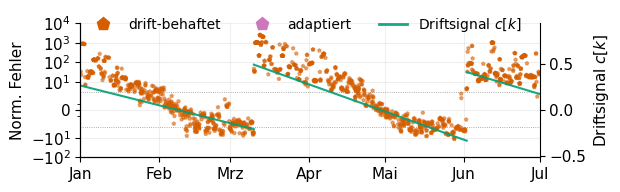

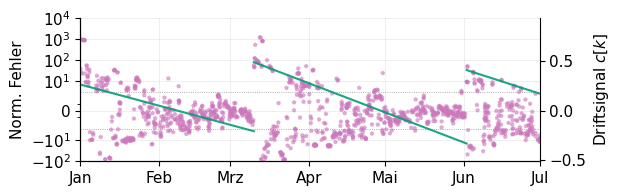

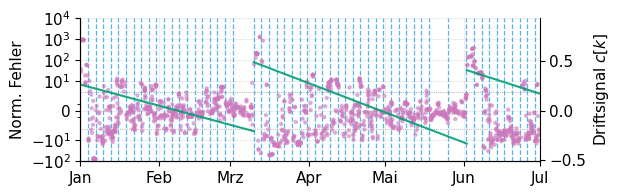

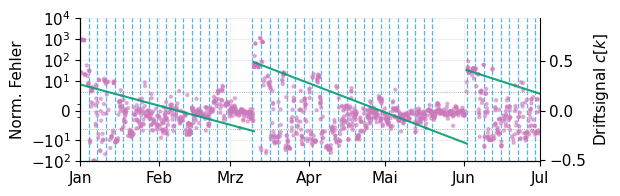

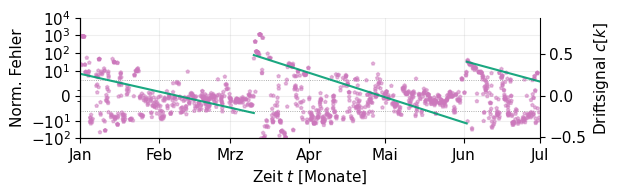

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

PLOT_END = pd.Timestamp("1970-07-01")
_mask_plot = time_index <= PLOT_END
t_plot = time_index[_mask_plot]
cd_plot = cd_signal[_mask_plot]
n_plot = len(t_plot)
cut = np.flatnonzero(np.diff(cd_plot) > 0) + 1   # noch fuer den RMSE-Verlauf unten

PANELS = [("baseline", "Baseline"), ("blind", "Blind"),
          ("informed", "Informed"), ("combined", "Combined"),
          ("blind_rec", "Blind+Rec")]

for k, (key, title) in enumerate(PANELS):
    res = seed_results[_medoid][key]
    role = "drift_afflicted" if key == "baseline" else "adapted"
    label = "drift-behaftet" if key == "baseline" else "adaptiert"

    fig, ax, ax2 = ts.error_timeseries(
        t_plot,
        [(res["errors_norm"][_mask_plot], role, label)],
        cd=cd_plot,
        detections=[t_plot[d] for d in res["detect_steps"] if d < n_plot],
        xlabel="Zeit $t$ [Monate]" if k == len(PANELS) - 1 else None,
        ylim=(-1e2, 1e4), frac=0.05, rng=rng,
        legend_series=[("drift_afflicted", "drift-behaftet"), ("adapted", "adaptiert")],
        legend=dict(bbox_to_anchor=[0.49, 1.15], loc="upper center", ncols=3) if k == 0 else False,
    )
    fig.tight_layout()
    if IS_FINAL:
        plot_store.save_figure(fig, f"adaptation_{key}", adapt_cfg,
                               final=IS_FINAL, savefig_kwargs={"dpi": 300},
                               archive_kwargs={"dpi": 300})
    plt.show()


## RMSE-Verlauf der Strategien

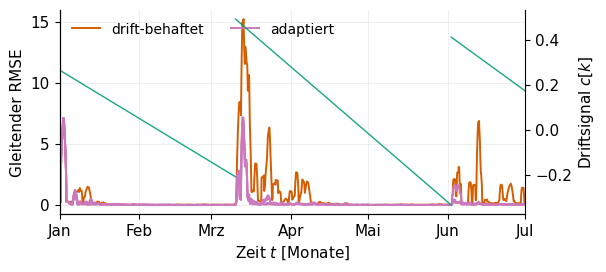

In [16]:
from matplotlib import dates as mdates
from src.utils import thesis_style as ts

WIN = max(10, 86400 // STEP_S)

fig, ax = plt.subplots(figsize=(ts.fig_width(), ts.fig_width(0.45)))

_adapt_labeled = False
for key, title in PANELS:
    e = pd.Series(seed_results[_medoid][key]["errors"], index=time_index)
    rmse_roll = np.sqrt((e ** 2).rolling(WIN, min_periods=1).mean())
    rmse_roll = rmse_roll[rmse_roll.index <= PLOT_END]
    if key == "baseline":
        _col, _lab = ts.C["drift_afflicted"], "drift-behaftet"
    else:
        _col = ts.C["adapted"]
        _lab = "adaptiert" if not _adapt_labeled else None
        _adapt_labeled = True
    ax.plot(rmse_roll.index, rmse_roll.values, color=_col, linewidth=1.4, label=_lab)

ax2 = ax.twinx()
for i, (a, b) in enumerate(zip(np.r_[0, cut], np.r_[cut, len(cd_plot)])):
    ax2.plot(t_plot[a:b], cd_plot[a:b], **ts.line("drift_signal", linewidth=1.0))
ax2.set_ylabel("Driftsignal $c[k]$")
ax2.spines["right"].set_visible(True)
ax2.spines["top"].set_visible(False)

ax.set_ylabel("Gleitender RMSE")
ax.set_xlabel("Zeit $t$ [Monate]")
ax.margins(x=0)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left", ncol=2, frameon=False)
fig.tight_layout()
plt.show()

## Numerische Auswertung

In [17]:
def _strategy_stats(res, c, rmse_baseline):
    e = np.asarray(res["errors"], float)
    c = np.asarray(c, float)
    rmse = float(np.sqrt(np.mean(e ** 2)))
    return dict(
        rmse=rmse,
        bias=float(np.mean(e)),
        sigma=float(np.std(e)),
        corr_abs=float(np.corrcoef(np.abs(e), np.abs(c))[0, 1]),
        n_train=int(len(res["train_steps"])),
        n_detect=int(len(res["detect_steps"])),
        n_reject=int(len(res.get("reject_steps", []))),
        n_recall=float(np.mean(res.get("recall_counts") or [0.0])),
        rmse_improvement=float(1.0 - rmse / rmse_baseline) if rmse_baseline else 0.0,
    )

# Kennzahlen ueber ALLE Seeds (Zelle 19) statt nur des Haupt-Seeds. Je Seed die
# Strategie-Statistik berechnen (RMSE-Verbesserung seed-intern gegen die eigene
# Baseline) und anschliessend zu Mittelwert und Streuung ueber die Seeds aggregieren.
_METRIC_COLS = ["rmse", "bias", "sigma", "corr_abs",
                "n_train", "n_detect", "n_reject", "n_recall", "rmse_improvement"]
_rows = [k for k, _ in PANELS]

_per_seed = {}
for _sd, _r in seed_results.items():
    _rb = float(np.sqrt(np.mean(np.asarray(_r["baseline"]["errors"], float) ** 2)))
    _per_seed[_sd] = {k: _strategy_stats(_r[k], cd_signal, _rb) for k in _rows}

# je Strategie ein (Seeds x Kennzahlen)-Block -> Mittelwert/Std ueber die Seeds
_stack = {row: pd.DataFrame([_per_seed[sd][row] for sd in seed_results])[_METRIC_COLS]
          for row in _rows}
stats_mean = pd.DataFrame({row: _stack[row].mean()       for row in _rows}).T[_METRIC_COLS]
stats_std  = pd.DataFrame({row: _stack[row].std(ddof=1)  for row in _rows}).T[_METRIC_COLS]

# stats = Seed-Mittel; treibt Tabelle/JSON/Makros. Die Abbildungen nutzen weiterhin
# den Medoid-Seed ueber seed_results[_medoid] (illustrative Zeitreihen).
stats = stats_mean

pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(f"Kennzahlen als Mittelwert ueber {len(seed_results)} Seeds:")
print(stats_mean.to_string())
print("\nStreuung (Std ueber Seeds):")
print(stats_std.to_string())

Kennzahlen als Mittelwert ueber 50 Seeds:
            rmse    bias  sigma  corr_abs  n_train  n_detect  n_reject  n_recall  rmse_improvement
baseline   1.663  0.4007  1.614    0.3724        0         0         0         0                 0
blind     0.6006 0.03827 0.5993    0.1848      121         0      0.78         0            0.6389
informed  0.6718 0.04266 0.6703    0.2162    176.6     111.3      3.86         0            0.5961
combined  0.6148 0.04467 0.6132    0.1867    232.5     95.88      4.66         0            0.6304
blind_rec 0.5864 0.03884 0.5851    0.1684      121         0      6.14     584.6            0.6475

Streuung (Std ueber Seeds):
               rmse      bias    sigma  corr_abs  n_train  n_detect  n_reject  n_recall  rmse_improvement
baseline  2.243e-16 5.607e-17        0 5.607e-17        0         0         0         0                 0
blind      0.004389  0.002075 0.004336  0.005242        0         0      0.79         0          0.002638
informed    0.075

## Seed-Robustheit — Verteilungsplot

RMSE-Verteilung je Strategie über alle Seeds als Violin + Box (`ts.violin_box`, Styling via `fig_width`). Baseline bleibt als deterministische Referenz aus dem Plot heraus und steht im Titel.

c:\git\process_optimization_concept_drift\.venv\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


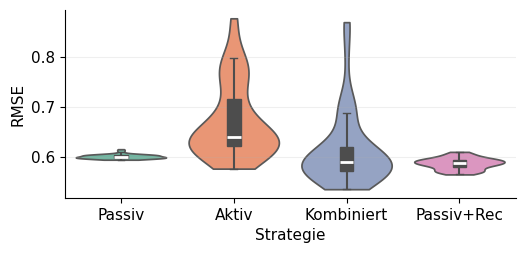

In [18]:
# Robustheits-Plot: Violin + Box (RMSE-Verteilung je Strategie ueber alle Seeds).
# Verteilungsplot ueber den arbeitsweit einheitlichen Helfer ts.violin_box; Styling
# via fig_width wie im uebrigen Notebook. Baseline bleibt draussen (deterministisch)
# und steht im Titel. Sinnvoll ab ~50 Seeds (N_SEED_RUNS), damit die KDE traegt.
import pandas as pd
from src.utils import thesis_style as ts

ts.fig_width()
_order = ["blind", "informed", "combined", "blind_rec"]
_labels = {"blind": "Passiv", "informed": "Aktiv", "combined": "Kombiniert", "blind_rec": "Passiv+Rec"}
_seeds = list(seed_results)
_long = pd.DataFrame({
    "Strategie": np.repeat([_labels[s] for s in _order], len(_seeds)),
    "RMSE": np.concatenate([seed_rmse.loc[s, _seeds].to_numpy(float) for s in _order]),
})

fig, ax = plt.subplots(figsize=(ts.fig_width(0.85), ts.fig_width(0.42)))
ts.violin_box(_long, "Strategie", "RMSE", order=[_labels[s] for s in _order],
              palette=ts.SET2[:len(_order)], ax=ax)
ax.set_ylabel("RMSE"); ax.set_xlabel("Strategie")
fig.tight_layout()
if IS_FINAL:
    plot_store.save_figure(fig, "adaptation_seed_violin", adapt_cfg,
                           final=IS_FINAL, savefig_kwargs={"dpi": 300},
                           archive_kwargs={"dpi": 300})
plt.show()


## Ergebnisse speichern

In [19]:
from src.utils import results_export as rx

# Kennzahlen sind nun Seed-Mittel (Zelle 26) -> durchgaengig als Dezimalzahl, auch
# n_train/n_detect/n_reject. Mittelwert -> "strategies", Streuung ueber die Seeds
# -> "strategies_std".
_keys = [(k, k, "num") for k in ["rmse", "bias", "sigma", "corr_abs",
                                 "n_train", "n_detect", "n_reject", "n_recall", "rmse_improvement"]]

doc = (rx.ResultDoc()
   .integer("n_samples", N)
   .integer("step_seconds", STEP_S)
   .integer("n_seeds", len(seed_results))
   .set("detectors_screened", list(DETECTORS))
   .set("informed_detector", BEST_DETECTOR)
   .set("screening", {d: {"rmse": float(v["rmse"]), "n_train": int(v["n_train"])}
                      for d, v in screening.items()})
   .set("config", ADAPT_CFG)
   .set("tuning", {
       "step_tune_seconds": int(STEP_TUNE_S),
       "n_trials": N_TRIALS,
       "weights": list(TUNE_WEIGHTS),
       "best_params": best_adapt_params,
   })
   .set("cooldown", {"tuned": True, "x_range": [0.0, 60.0], "t_stat_points": float(T_stat)})
   .set("applied_config", applied_cfg)
   .stats(stats_mean, _keys, into="strategies",     rows=[k for k, _ in PANELS])
   .stats(stats_std,  _keys, into="strategies_std", rows=[k for k, _ in PANELS]))

if "seed_rmse" in dir():
    doc.set("seed_eval", {
        "seeds": [int(s) for s in SEEDS],
        "rmse": {s: {"mean": float(seed_rmse.loc[s, "mean"]),
                     "std": float(seed_rmse.loc[s, "std"])} for s in STRATEGIES},
    })

doc.save(res_store, "adaptation", adapt_cfg, final=IS_FINAL)

Umfassende Ergebnisse -> C:\git\process_optimization_concept_drift\results\syn_adaptation.json


'C:\\git\\process_optimization_concept_drift\\results\\syn_adaptation.json'

In [20]:
from src.utils import latex_export as lx

mx = lx.MacroExport("Automatisch erzeugt aus syn_adaptation.ipynb - nicht manuell editieren")

mx.comment("Parameter (Hash-relevant)")
mx.param("paramTa",     STEP_S,      unit=r"\second")
mx.param("paramTaTune", STEP_TUNE_S, unit=r"\second")
mx.param("paramNPoints", N)
mx.param("paramChunk",   CHUNK)
mx.param("paramNScreenSeeds", len(SCREENING_SEEDS), spell_out=True)

mx.comment("Detektor-Screening (Gleichstandsregel)")
# Anzeigenamen der Detektoren fuer den Fliesstext. Der Schwellwert-Detektor hat
# kein eigenes Akronym, die uebrigen werden ueber \ac{...} gesetzt.
_DET_LABEL = {"RMSE": "Schwellwert-Detektor", "DDM": r"\ac{DDM}",
              "EDDM": r"\ac{EDDM}", "ADWIN": r"\ac{ADWIN}", "KSWIN": r"\ac{KSWIN}"}
mx.num("paramTieAlpha", TIE_ALPHA, 2)
mx.raw("paramTieOrder", ", ".join(_DET_LABEL[d] for d in TIE_ORDER))
mx.raw("adaptScreenLead", _DET_LABEL[SCREEN_LEAD])
mx.raw("adaptDetector",   _DET_LABEL[BEST_DETECTOR])

mx.comment("Ergebnisse (Adaptionskennzahlen je Strategie; Mittelwert und Std ueber alle Seeds)")
mx.integer("adaptNSeeds", len(seed_results))
_name_map = {"baseline": "Baseline", "blind": "Blind",
             "informed": "Informed", "combined": "Combined", "blind_rec": "BlindRec"}
# (Spalte, Suffix, Nachkommastellen). Nachtrainings/Detektionen sind als Seed-Mittel
# nicht mehr ganzzahlig und werden daher mit einer Nachkommastelle ausgegeben. Zu
# jeder Kennzahl wird zusaetzlich die Streuung ueber die Seeds als ...Std-Makro
# erzeugt (fuer die "Mittelwert +/- Std"-Darstellung in der Tabelle).
_keys = [("rmse", "Rmse", 3), ("bias", "Bias", 3), ("sigma", "Sigma", 3),
         ("corr_abs", "CorrAbs", 2), ("rmse_improvement", "Improve", 3),
         ("n_train", "NTrain", 1), ("n_detect", "NDetect", 1), ("n_recall", "NRecall", 1)]
for k, _ in PANELS:
    m = _name_map[k]
    for col, suf, nd in _keys:
        mx.num(f"adapt{m}{suf}",    stats_mean.loc[k, col], nd)
        mx.num(f"adapt{m}{suf}Std", stats_std.loc[k, col],  nd)
    mx.num(f"adapt{_name_map[k]}RmseMin", seed_rmse.loc[k, list(seed_results)].min(), 3)

mx.save(res_store, "adaptation", adapt_cfg, final=IS_FINAL)

LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\syn_adaptation.tex

% Automatisch erzeugt aus syn_adaptation.ipynb - nicht manuell editieren

% Parameter (Hash-relevant)
\newcommand{\paramTa}{\SI{600}{\second}}
\newcommand{\paramTaTune}{\SI{3600}{\second}}
\newcommand{\paramNPoints}{52560}
\newcommand{\paramChunk}{144}
\newcommand{\paramNScreenSeeds}{fünf}

% Detektor-Screening (Gleichstandsregel)
\newcommand{\paramTieAlpha}{0{,}05}
\newcommand{\paramTieOrder}{Schwellwert-Detektor, \ac{DDM}, \ac{EDDM}, \ac{ADWIN}, \ac{KSWIN}}
\newcommand{\adaptScreenLead}{\ac{KSWIN}}
\newcommand{\adaptDetector}{Schwellwert-Detektor}

% Ergebnisse (Adaptionskennzahlen je Strategie; Mittelwert und Std ueber alle Seeds)
\newcommand{\adaptNSeeds}{50}
\newcommand{\adaptBaselineRmse}{1{,}663}
\newcommand{\adaptBaselineRmseStd}{0{,}000}
\newcommand{\adaptBaselineBias}{0{,}401}
\newcommand{\adaptBaselineBiasStd}{0{,}000}
\newcommand{\adaptBaselineSigma}{1{,}614}
\newcommand{\adaptBaselineSigm

'C:\\git\\process_optimization_concept_drift\\results\\syn_adaptation.tex'